# **Frequentist Approach**

## **Fisher scoring (general)**

We implement Fisher scoring in a *general* way.  
Given a design matrix $X \in \mathbb{R}^{n \times p}$ and a vector $Y \in \mathbb{R}^{n}$, each iteration:

1. computes the linear predictor $\eta^{(t)} = X\beta^{(t)}$;

2. calls a family-specific function `f(eta, Y)` returning:
   - $\mu^{(t)}$: the mean vector,
   - $W^{(t)}$: the diagonal weight matrix, that is $W^{(t)} = \operatorname{diag}(w_i)$
   - $z^{(t)} = \eta^{(t)} + (y - \mu^{(t)})/w$


3. updates $\beta$:
   $$
   \beta^{(t+1)}
   =
   \left( X^\top W^{(t)} X \right)^{-1}
   X^\top W^{(t)} z^{(t)} .
   $$


The algorithm stops when the modified relative change
$$
\frac{\|\beta^{(t+1)}-\beta^{(t)}\|}{\|\beta^{(t)}\|+\texttt{eps}}
$$
falls below `tol`.


In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import os

In [2]:
def fisher_scoring(X, Y, f, eps=1e-6, max_iter=100, verbose=True):
    X = np.asarray(X, dtype=float)
    Y = np.asarray(Y, dtype=float).reshape(-1, 1)

    n, p = X.shape
    beta = np.zeros((p, 1))
    converged = False
    rel_change_path = []

    for it in range(max_iter):
        eta = X @ beta  

        mu, W, z = f(eta, Y) # function specific to the type of regression

        A = X.T @ W @ X
        b = X.T @ W @ z

        beta_new = np.linalg.inv(A) @ b

        mod_rel_conv = np.linalg.norm(beta_new - beta) / (np.linalg.norm(beta) + eps)
        rel_change_path.append(mod_rel_conv)

        if verbose:
            print(f"iter {it+1} modified relative change {mod_rel_conv}")

        beta = beta_new

        if mod_rel_conv < eps:
            converged = True
            break

    return beta.ravel(), converged, rel_change_path

# **Bayesian Approach**


## **Metropolis Hastings within Gibbs**

We implement a component-wise Metropolis–Hastings sampler to draw from the posterior of the GLM coefficients: the target distribution is the (log-)posterior function `log_posterior(beta) = log_likelihood(beta) + log_prior(beta)` (known up to an additive constant). Since the full conditionals are not available in closed form, we update the coefficients one at a time performing a Metropolis Hastings component-wise that builds an ergodic Markov chain yielding the posterior distribution as the stationary distribution.

Given an initial vector $\beta^{(0)} \in \mathbb{R}^p$ and a `step_size`, each iteration `t = 1,...,n_samples` performs a run over all coordinates:

1. for each component $i = 1,\dots,p$:
   - propose a new coefficient by a random-walk step `beta_prop[i] = beta[i] + step_size * N(0,1)` (all other coordinates stay equal to the current vector);
   - compute `delta = log_posterior(beta_prop) - log_posterior(beta_current)`;
   - accept the proposed move with probability `min(1, exp(delta))`, otherwise keep the old value.

2. after one full iteration for each beta, the chain stores the new vector beta. We mesured empirically that this leads to a faster chain (more acceptance) compared to an algorithm that proposes an overall change in the whole vector. Conceptually, this may happen because over many dimensions, even one bad guess on a specific beta can prevent acceptance of the overall beta.

After the run:
- we discard the first `burn_in` iterations (burn-in);
- the remaining draws `samples_post` are treated as approximate samples from the posterior;
- we return:
  - acceptance rate per component,
  - overall acceptance rate (over all component updates),
  - posterior draws `samples_post` (used for posterior means, SDs, trace plots, ACF).



In [3]:
def componentwise_mh(X, Y, log_posterior, beta_initial, step_size, n_samples, burn_in, random_seed):
   
    rng = np.random.default_rng(random_seed)
    beta = beta_initial
    p = beta.size
    chain = np.zeros((n_samples, p))
    accepts_dim = np.zeros(p)
    trials_dim  = np.zeros(p) 
    log_posterior_current = log_posterior(X, Y, beta)

    for trial in range(n_samples):
        for i in range(p): # Iterating component-wise
            if trial >= burn_in: 
                trials_dim[i] += 1
            beta_proposed = beta.copy()
            beta_proposed[i] = beta[i] + step_size * rng.standard_normal()

            log_posterior_proposed = log_posterior(X, Y, beta_proposed)
            delta = log_posterior_proposed - log_posterior_current

            if delta >= 0 or np.log(rng.uniform(0,1)) < delta: # Acceptance probability
                beta = beta_proposed
                log_posterior_current = log_posterior_proposed
                if trial >= burn_in:
                    accepts_dim[i] += 1

        chain[trial] = beta # Saving new beta vector in the chain

    acceptance_overall = accepts_dim.sum() / trials_dim.sum()
    accept_rate_per_dim = accepts_dim / trials_dim
    samples_post = chain[burn_in:, :]
    return accept_rate_per_dim, acceptance_overall, samples_post

## **Step size tuning criterion**

We needed to tune the variance parameter of the proposal distribution (the step size in the random-walk Metropolis–Hastings algorithm).
The problem we had was:

- If the proposal variance was too small, most proposals are accepted but successive samples are very close,
  leading to high autocorrelation and slow exploration.
- If the proposal variance was too large, most proposals are rejected, so the chain remains stuck for many
  iterations, again resulting in high autocorrelation.

In both cases, the Markov chain converges to the correct stationary distribution, but in an inefficient way.

To select an appropriate proposal scale, we use an autocorrelation-based criterion.
For each component $\beta_j$, the cumulative autocorrelation is approximated as
$$
\sum_{k=1}^{K} \rho_j(k),
$$
where $\rho_j(k)$ denotes the autocorrelation at lag $k$.  
The sum is truncated either at a fixed maximum lag (e.g. $K=40$) or when $\rho_j(k)$ becomes non-positive.

Since posterior inference is performed component-wise (means, standard deviations, credible intervals),
we define (in the applications of the algorithm) the tuning criterion as the worst cumulative autocorrelation across components:
$$
\max_{j=1,\ldots,p} \sum_{k=1}^{K} \rho_j(k).
$$

The proposal scale is chosen as the value that minimizes this quantity across step sizes, ensuring efficient mixing for all
parameters.

In [4]:
def acf_per_component(chain_at_component):    
    max_lag = 40
    denominator = 0
    total_acf = 0

    x = chain_at_component.copy()
    sample_mean = x.mean()
    
    for sample in range(len(x)):
        x[sample] -= sample_mean
        denominator += x[sample]**2
        
    for lag in range(1, max_lag+1):
        numerator = 0
        for sample in range(len(x)-lag):
            numerator += x[sample] * x[sample+lag]

        corr_at_lag = numerator / denominator
        if corr_at_lag <= 0:
            break

        total_acf += corr_at_lag

    return total_acf

# **Application of the algorithms** 

## **A - Credit Card dataset (Logistic Regression)**

We begin by loading and preprocessing data.

In [5]:
base_df = os.getcwd()
path_logistic = os.path.join(base_df, "Data", "CreditCard.csv")

df_logistic = pd.read_csv(path_logistic)
df_logistic = df_logistic.drop(columns=["share", "expenditure"]).copy()

binary_cols_logistic = ["card", "owner", "selfemp"]
for col in binary_cols_logistic:
    df_logistic[col] = df_logistic[col].map({"yes": 1, "no": 0})

Y_logistic = df_logistic["card"].to_numpy(dtype=float)
X_df_logistic = df_logistic.drop(columns=["card"]).copy()

bin_pred_cols = ["owner", "selfemp"]
numeric_cols = [c for c in X_df_logistic.columns if c not in bin_pred_cols]
for col in numeric_cols:
    mu = X_df_logistic[col].mean()
    sd = X_df_logistic[col].std(ddof=0)
    X_df_logistic[col] = (X_df_logistic[col] - mu) / sd

X_raw_logistic = X_df_logistic.to_numpy(dtype=float)
X_logistic = np.column_stack([np.ones(X_raw_logistic.shape[0]), X_raw_logistic])
beta_names_logistic = ["intercept"] + list(X_df_logistic.columns)


In this dataset, the variable target we want to analyze is a binary variable.  
For binary data, we assume
$$
Y_i \sim \mathrm{Bernoulli}(p_i), \qquad i=1,\dots,n.
$$
In the context of GLM, this formulation is called the **random component**. The **systematic component** is the linear predictor $\eta$ that we defined earlier
The Bernoulli distribution belongs to the exponential family and can be written as
$$
\Pr(Y_i = y_i)
=
\exp\!\left\{
y_i \log\!\left(\frac{p_i}{1-p_i}\right)
+
\log(1-p_i)
\right\}.
$$

Thus, the **canonical parameter** is

$$
\theta_i = \log\!\frac{p_i}{1-p_i}
$$

Therefore, for the Bernoulli distribution the **canonical link** is the **logit function**.    
  
### *A.1 - MLE via Fisher Scoring*
Now we define the function that will be fed into the Fisher scoring algorithm pipeline.    

First, we retrieve the inverse of the link function, obtaining the mean
$$
\mu_i = \frac{1}{1 + e^{-\eta_i}}
$$
as a function of the linear predictor $\eta_i$.

Under a canonical link, the diagonal weight matrix $W$ contains the variances
of the response distribution. In the Bernoulli case,
$$
\operatorname{Var}(Y_i) = \mu_i(1-\mu_i),
$$
and therefore $W = \mathrm{diag}(\mu_i(1-\mu_i))$.

Finally, we define $z_i$, which under the canonical link, simplifies to
$$
z_i = \eta_i + \frac{y_i - \mu_i}{\mu_i(1-\mu_i)}.
$$

In [6]:
def values_logistic(eta, y):
    mu = 1.0 / (1.0 + np.exp(-eta))
    
    w = (mu * (1 - mu)).ravel() # Variance of a Bernoulli = mu(1-mu)
    W = np.diag(w)                  
    
    z = eta + (y - mu) / w.reshape(-1, 1)   
    
    return mu, W, z

beta_hat_logistic, convergence_logistic, rel_change_path_logistic = fisher_scoring(X_logistic, Y_logistic, values_logistic)

eta_hat_logistic = X_logistic @ beta_hat_logistic

mu_hat_logistic = 1.0 / (1.0 + np.exp(-eta_hat_logistic))  

iter 1 modified relative change 1398726.3830851356
iter 2 modified relative change 0.6513109608389418
iter 3 modified relative change 0.29155222484952287
iter 4 modified relative change 0.07869601362757565
iter 5 modified relative change 0.005916753199885816
iter 6 modified relative change 3.380996426725579e-05
iter 7 modified relative change 1.1139563027510968e-09


From standard asymptotic properties of maximum likelihood estimators, we know that
the estimator $\hat{\beta}$ is asymptotically normal:
$$
\sqrt{n}\,\bigl(\hat{\beta} - \beta_{\text{true}}\bigr)
\;\xrightarrow{d}\;
\mathcal{N}\!\left(0,\, I(\beta_{\text{true}})^{-1}\right)
$$
where $\mathcal{I}(\beta)$ denotes the Fisher information.
Therefore, by Slutsky the asymptotic covariance matrix of $\hat{\beta}$ is
$$
\operatorname{Var}(\hat{\beta}) \approx (X^\top W X)^{-1}.
$$

We use this result to perform a significance check on the estimated coefficients
via Wald tests.


In [7]:
# Basic inference
w_logistic  = (mu_hat_logistic * (1 - mu_hat_logistic)).ravel() 
W_logistic   = np.diag(w_logistic)

cov_hat_logistic = np.linalg.inv(X_logistic.T @ W_logistic @ X_logistic) # Fisher information of the sample is the asymptotic covariance
se_hat_logistic  = np.sqrt(np.diag(cov_hat_logistic))
zcrit = 1.96 
ci_lower_fisher_l = beta_hat_logistic - zcrit * se_hat_logistic
ci_upper_fisher_l = beta_hat_logistic + zcrit * se_hat_logistic

# Summary
out_logistic = pd.DataFrame({
    "CI 2.5%": ci_lower_fisher_l,
    "FisherScoring_scratch": beta_hat_logistic,
    "CI 97.5%": ci_upper_fisher_l,
    "se": se_hat_logistic,
    "z": beta_hat_logistic / se_hat_logistic
}, index=beta_names_logistic)

out_rounded_logistic = out_logistic.round(4) 

out_rounded_logistic["abs_z"] = out_rounded_logistic["z"].abs()
out_rounded_logistic.sort_values("abs_z", ascending=False) # ordering by significance (Wald)

,CI 2.5%,FisherScoring_scratch,CI 97.5%,se,z,abs_z
reports,-2.7274,-2.3556,-1.9837,0.1897,-12.4167,12.4167
intercept,1.0579,1.2998,1.5417,0.1234,10.5334,10.5334
active,0.6013,0.8339,1.0665,0.1187,7.0267,7.0267
income,0.1700,0.3832,0.5964,0.1088,3.5229,3.5229
dependents,-0.4714,-0.3022,-0.1331,0.0863,-3.5022,3.5022
majorcards,0.0508,0.1953,0.3398,0.0737,2.6488,2.6488
selfemp,-1.3239,-0.7573,-0.1908,0.2891,-2.6200,2.6200
owner,0.0859,0.4783,0.8706,0.2002,2.3891,2.3891
age,-0.3176,-0.1269,0.0638,0.0973,-1.3043,1.3043
months,-0.1472,0.0338,0.2148,0.0924,0.3662,0.3662


Now we just use a built-in function that performs the same algorithm to check the robustness of our results

In [8]:
logit_sm = sm.GLM(
    Y_logistic,
    X_logistic,
    family=sm.families.Binomial()
).fit()

beta_mle_logistic = logit_sm.params
cov_mle_logistic = logit_sm.cov_params()

# COMPARISON DATAFRAME

comparison_logistic = pd.DataFrame({
    "FisherScoring_scratch": beta_hat_logistic,
    "MLE_builtin": beta_mle_logistic,
    "diff": beta_hat_logistic - beta_mle_logistic
}, index=beta_names_logistic)

comparison_logistic

,FisherScoring_scratch,MLE_builtin,diff
intercept,1.299796,1.299796,1.006928e-11
reports,-2.355576,-2.355576,-8.148149e-11
age,-0.126882,-0.126882,-1.396355e-12
income,0.383176,0.383176,4.996559e-12
owner,0.478272,0.478272,-7.671086e-13
selfemp,-0.757343,-0.757343,-9.302781e-12
dependents,-0.302223,-0.302223,-1.334099e-12
months,0.033824,0.033824,3.425163e-12
majorcards,0.195281,0.195281,2.546657e-12
active,0.833914,0.833914,3.528777e-11


### *A.2 - Bayesian Logistic Regression*

In the bayesian model we define: 

- **Priors**: $\beta \sim \mathcal{N}(0, 4)$ for all beta's except intercept $\beta_0 \sim \mathcal{N}(0, 9)$
- **likelihood**: Bernoulli with logistic link, $P(Y_i=1\mid X_i,\beta)={1+\exp(-X_i^\top\beta)}^{-1}$
- **log_posterior**: (proportional to) the sum of log prior and log likelihood


In [9]:
def log_likelihood_logistic(X, y, beta): 
    eta = X @ beta                           
    p = 1/(1+np.exp(-eta))                   
    p = np.clip(p, 1e-15, 1 - 1e-15) # numerical constraint to avoid -inf values if a very unlikely y_i occurs
    log_likelihood_logistic = np.sum(y * np.log(p) + (1-y) * np.log(1-p)) 
    return log_likelihood_logistic        

def log_prior_logistic(beta):
    beta = np.asarray(beta).reshape(-1)
    var_intercept = 9
    var_others = 4
    # dropping costants 
    log_prior_logistic = -0.5 * (beta[0]**2 / var_intercept + np.sum(beta[1:]**2 / var_others))
    return log_prior_logistic      

def log_posterior_logistic(X, Y, beta): 
    return log_likelihood_logistic(X, Y, beta) + log_prior_logistic(beta) 

At first we define the best step as the one that minimizes the highest ACF_component. We evaluated many more values than the 
grid [0.2, 0.30], however since each test is quite computational expensive we left just this sample that contains the best value we found overall. 

Once we find the best step, we define the model acceptance rate and we perform inference on the parameters through mean and sd. 
Then we show an overall summary between the values found in frequentist and bayes inference.

Lastly, we show a trace plot of the variable "income" (which shows reached stationarity in the mean) and a graph of ACF of the same parameter (which shows decay to 0 approximately at lag 15).

In [10]:
n_samples_logistic = 20000
burn_in_logistic = 5000
random_seed_logistic = 0
beta_initial_logistic = beta_hat_logistic
steps_logistic = np.arange(0.2,0.31, 0.05)
best_acf_logistic = np.inf
best_step_logistic = 0
components_logistic = X_logistic.shape[1]

# Optimizing the step size 

for step in steps_logistic:                                     
    step_vector_logistic = step * np.ones(components_logistic,)
    acceptance_vector_logistic, acceptance_overall_logistic, samples_post_logistic = componentwise_mh(X_logistic, Y_logistic, log_posterior_logistic, beta_initial_logistic, step, n_samples_logistic, burn_in_logistic, random_seed_logistic)
    max_acf_step_logistic = 0
    for beta_n in range(components_logistic):
        trial = acf_per_component(samples_post_logistic[:, beta_n])
        if trial > max_acf_step_logistic:
            max_acf_step_logistic = trial
    if max_acf_step_logistic < best_acf_logistic:
        best_step_logistic = step
        best_acf_logistic = max_acf_step_logistic
        
    print(f'We are testing the step {step.round(2)}, which makes the acceptance rate {(acceptance_overall_logistic*100).round(2)}% and the overall ACF of the worst component equal to {max_acf_step_logistic.round(2)}')

print(f'At the end of the trials, the best step is {best_step_logistic.round(2)} which generates a model with the following description: ')

# Calling the function with the optimized step size

acceptance_vector_logistic, acceptance_overall_logistic, samples_post_logistic = componentwise_mh(X_logistic, Y_logistic, log_posterior_logistic, beta_initial_logistic, best_step_logistic, n_samples_logistic, burn_in_logistic, random_seed_logistic)

post_mean_logistic = samples_post_logistic.mean(axis=0)
post_sd_logistic  = samples_post_logistic.std(axis=0)
cred_i_lower_l = np.percentile(samples_post_logistic, 2.5, axis=0)
cred_i_upper_l = np.percentile(samples_post_logistic, 97.5, axis=0)

summary_logistic = pd.DataFrame({
    "2.5% cred. i.": cred_i_lower_l,
    "Post mean": post_mean_logistic,
    "97.5% cred. i.": cred_i_upper_l,
    "Post sd": post_sd_logistic,
    "Acceptance rate": acceptance_vector_logistic,
    "Diff with GLM": post_mean_logistic - beta_initial_logistic
}, index=beta_names_logistic)

print(f'The overall acceptance rate of the model is: {(acceptance_overall_logistic*100).round(2)}%')
summary_logistic.round(4)

We are testing the step 0.2, which makes the acceptance rate 51.0% and the overall ACF of the worst component equal to 8.19
We are testing the step 0.25, which makes the acceptance rate 44.41% and the overall ACF of the worst component equal to 7.79
We are testing the step 0.3, which makes the acceptance rate 39.01% and the overall ACF of the worst component equal to 10.29
At the end of the trials, the best step is 0.25 which generates a model with the following description: 
The overall acceptance rate of the model is: 44.41%


,2.5% cred. i.,Post mean,97.5% cred. i.,Post sd,Acceptance rate,Diff with GLM
intercept,1.0699,1.3095,1.5581,0.1258,0.3679,0.0098
reports,-2.7412,-2.3643,-2.0053,0.1884,0.5703,-0.0088
age,-0.3119,-0.1241,0.0671,0.0972,0.3685,0.0028
income,0.1828,0.3925,0.6144,0.1091,0.4144,0.0093
owner,0.0954,0.4792,0.8704,0.2019,0.5353,0.0009
selfemp,-1.2947,-0.7386,-0.1521,0.2937,0.7268,0.0187
dependents,-0.4706,-0.3031,-0.1314,0.0865,0.3599,-0.0009
months,-0.1362,0.0367,0.2273,0.0924,0.3668,0.0028
majorcards,0.0458,0.1950,0.3451,0.0748,0.3362,-0.0002
active,0.5986,0.8294,1.0624,0.1186,0.3947,-0.0045


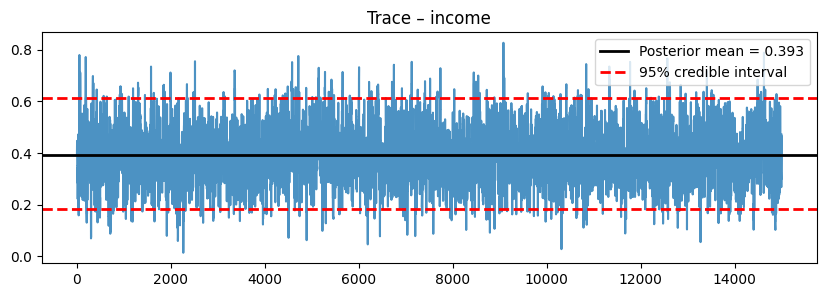

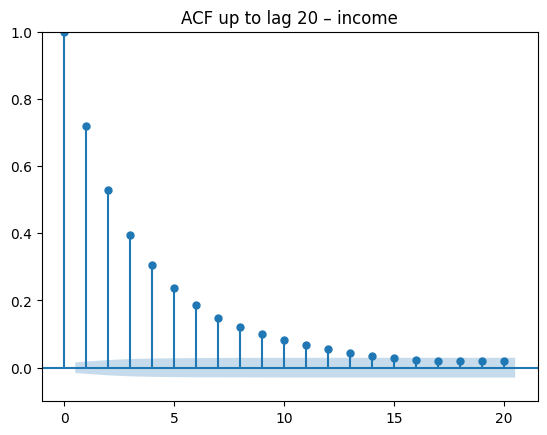

In [11]:
j_income = beta_names_logistic.index("income")
sample_income = samples_post_logistic[:, j_income]

mean_income = sample_income.mean()
ci_lower, ci_upper = np.percentile(sample_income, [2.5, 97.5])  # scalars

plt.figure(figsize=(10, 3))
plt.plot(sample_income, alpha=0.8)

plt.axhline(mean_income, color="black", linestyle="-", linewidth=2,
            label=f"Posterior mean = {mean_income:.3f}")

plt.axhline(ci_lower, color="red", linestyle="--", linewidth=2,
            label="95% credible interval")
plt.axhline(ci_upper, color="red", linestyle="--", linewidth=2)

plt.title("Trace – income")
plt.legend()
plt.show()

sm.graphics.tsa.plot_acf(sample_income, lags=20)
plt.title("ACF up to lag 20 – income")
plt.ylim(-0.1, 1)
plt.show()

In [12]:
out_rounded_logistic = out_rounded_logistic.sort_values("abs_z", ascending=False) 
report_logistic = (
    out_rounded_logistic[['CI 2.5%', 'FisherScoring_scratch', 'CI 97.5%']]
    .merge(
        summary_logistic[["2.5% cred. i.", "Post mean", "97.5% cred. i.", "Acceptance rate"]],
        left_index=True,
        right_index=True
    )
)
report_logistic

,CI 2.5%,FisherScoring_scratch,CI 97.5%,2.5% cred. i.,Post mean,97.5% cred. i.,Acceptance rate
reports,-2.7274,-2.3556,-1.9837,-2.741198,-2.364348,-2.005326,0.570267
intercept,1.0579,1.2998,1.5417,1.069863,1.309550,1.558102,0.367933
active,0.6013,0.8339,1.0665,0.598620,0.829424,1.062429,0.394667
income,0.1700,0.3832,0.5964,0.182778,0.392503,0.614397,0.414400
dependents,-0.4714,-0.3022,-0.1331,-0.470585,-0.303103,-0.131423,0.359933
majorcards,0.0508,0.1953,0.3398,0.045776,0.195035,0.345112,0.336200
selfemp,-1.3239,-0.7573,-0.1908,-1.294678,-0.738613,-0.152115,0.726800
owner,0.0859,0.4783,0.8706,0.095402,0.479157,0.870429,0.535267
age,-0.3176,-0.1269,0.0638,-0.311886,-0.124090,0.067129,0.368467
months,-0.1472,0.0338,0.2148,-0.136209,0.036670,0.227263,0.366800


## **B - azcabgptc dataset (Poisson Regression)**

### *B.1 - MLE via Fisher Scoring*
In this dataset, the target variable we want to analyze is a **count variable**.
For count data, we assume

$$
Y_i \sim \mathrm{Poisson}(\mu_i), \qquad i = 1,\ldots,n.
$$

In the context of GLMs, this is the **random component**.  
As before, the **systematic component** is the linear predictor $\eta$. Also Poisson belongs to the exponential family and so can be rewritten as

$$
\exp\left\{ y_i \log(\mu_i) - \mu_i - \log(y_i!) \right\}.
$$

Thus, the **canonical parameter** is

$$
\theta_i = \log(\mu_i).
$$

Therefore, for the Poisson distribution the **canonical link** is the **log link**.  

We begin by loading and preprocessing data.

In [13]:
base_df= os.getcwd()
path_poisson = os.path.join(base_df, "Data", "azcabgptca.csv")
df_poisson = pd.read_csv(path_poisson)

Y_poisson = df_poisson["los"].to_numpy(dtype=float)
X_df_poisson = df_poisson.drop(columns=["los"]).copy()

for col in X_df_poisson:
    mu_poisson = X_df_poisson[col].mean()
    sd_poisson = X_df_poisson[col].std(ddof=0)
    X_df_poisson[col] = (X_df_poisson[col] - mu_poisson) / sd_poisson

X_raw_poisson = X_df_poisson.to_numpy(dtype=float)
X_poisson = np.column_stack([np.ones(X_raw_poisson.shape[0]), X_raw_poisson])
beta_names_poisson = ["intercept"] + list(X_df_poisson.columns)

For the Poisson model with log link, the inverse link function gives the mean

$$
\mu_i = \exp(\eta_i).
$$

which is equal to the variance for a Poisson. Under the canonical link, this implies that the diagonal weight matrix is

$$
W = \mathrm{diag}(\mu_1,\ldots,\mu_n).
$$

Therefore 

$$
z_i = \eta_i + \frac{y_i - \mu_i}{\mu_i}.
$$


In [14]:
def values_poisson(eta, y):

    mu = np.exp(eta)
       
    W = np.diag(mu.flatten())  # Variance of poisson = mu  
    
    z = eta + (y - mu) / mu 
    
    return mu, W, z

beta_hat_poisson, convergence_poisson, rel_change_path_poisson = fisher_scoring(X_poisson, Y_poisson, values_poisson)

eta_hat_poisson = X_poisson @ beta_hat_poisson

mu_hat_poisson = mu_hat_poisson = np.exp(eta_hat_poisson) 

iter 1 modified relative change 7429281.929531535
iter 2 modified relative change 0.12334950963309005
iter 3 modified relative change 0.12385152248495475
iter 4 modified relative change 0.12198412629261411
iter 5 modified relative change 0.1315968386947192
iter 6 modified relative change 0.1482871959684539
iter 7 modified relative change 0.16587885748626321
iter 8 modified relative change 0.1797694896193605
iter 9 modified relative change 0.18322122701509172
iter 10 modified relative change 0.16060102145867497
iter 11 modified relative change 0.08408884864579497
iter 12 modified relative change 0.015263870112507547
iter 13 modified relative change 0.0003948672069241518
iter 14 modified relative change 2.5292788769302165e-07


We perform the same significance checks performed for the logistic regression

In [15]:
# Basic inference
W_poisson = np.diag(mu_hat_poisson.ravel())

cov_hat_poisson = np.linalg.inv(X_poisson.T @ W_poisson @ X_poisson) # Fisher information of the sample is the asymptotic covariance
se_hat_poisson  = np.sqrt(np.diag(cov_hat_poisson))
zcrit = 1.96 
ci_lower_glm_p = beta_hat_poisson - zcrit * se_hat_poisson
ci_upper_glm_p = beta_hat_poisson + zcrit * se_hat_poisson

# Summary
out_poisson = pd.DataFrame({
    "CI 2.5%": ci_lower_glm_p,
    "FisherScoring_scratch": beta_hat_poisson,
    "CI 97.5%": ci_upper_glm_p,
    "se": se_hat_poisson,
    "z": beta_hat_poisson / se_hat_poisson
}, index=beta_names_poisson)

out_rounded_poisson = out_poisson.round(4)

out_rounded_poisson["abs_z"] = out_rounded_poisson["z"].abs()
out_rounded_poisson.sort_values("abs_z", ascending=False) # ordering by significance (Wald)

,CI 2.5%,FisherScoring_scratch,CI 97.5%,se,z,abs_z
intercept,1.8119,1.8310,1.8501,0.0097,188.2642,188.2642
procedure,0.5457,0.5643,0.5829,0.0095,59.4164,59.4164
type,0.0779,0.0943,0.1108,0.0084,11.2432,11.2432
gender,-0.0654,-0.0489,-0.0325,0.0084,-5.8264,5.8264
age,0.0267,0.0432,0.0597,0.0084,5.1388,5.1388
died,-0.0571,-0.0412,-0.0254,0.0081,-5.1042,5.1042


Also in this case, we check the robustness of our results

In [16]:
poisson_sm = sm.GLM(
    Y_poisson,
    X_poisson,
    family=sm.families.Poisson()
).fit()

beta_mle_poisson = poisson_sm.params
cov_mle_poisson = poisson_sm.cov_params()

# COMPARISON DATAFRAME

comparison_poisson = pd.DataFrame({
    "FisherScoring_scratch": beta_hat_poisson,
    "MLE_builtin": beta_mle_poisson,
    "diff": beta_hat_poisson - beta_mle_poisson
}, index=beta_names_poisson)

comparison_poisson

,FisherScoring_scratch,MLE_builtin,diff
intercept,1.831007,1.831007,1.174616e-13
died,-0.041247,-0.041247,-1.840195e-14
procedure,0.564315,0.564315,4.551914e-14
age,0.043198,0.043198,6.254719e-14
gender,-0.048939,-0.048939,-1.148664e-13
type,0.094338,0.094338,8.927581e-14


### *B.2 - Bayesian Poisson Regression*

In the bayesian model we define: 

- **Priors**: $\beta \sim \mathcal{N}(0, 1)$ for all beta's except intercept $\beta_0 \sim \mathcal{N}(0, 4)$
- **likelihood**: Poisson with log link $Y_i\mid X_i,\beta \sim \mathrm{Poisson}(\exp(X_i^\top\beta))$
- **log_posterior**: (proportional to) the sum of log prior and log likelihood

In [17]:
def log_likelihood_poisson(X, y, beta):
    eta = X @ beta                      
    lam = np.exp(eta)
    log_likelihood_poisson = np.sum(y * eta - lam)
    return log_likelihood_poisson

def log_prior_poisson(beta):
    beta = np.asarray(beta).reshape(-1)
    var_intercept = 4
    var_others = 1
    # dropping costants 
    log_prior_poisson = -0.5 * (beta[0]**2 / var_intercept + np.sum(beta[1:]**2 / var_others))
    return log_prior_poisson

def log_posterior_poisson(X, Y, beta):
    return log_likelihood_poisson(X, Y, beta) + log_prior_poisson(beta)

At first we define the best step as the one that minimizes the highest ACF_component. We evaluated many more values than the 
grid [0.01, 0.025], however since each test is quite computational expensive we left just this sample that contains the best value we found overall. 

Once we find the best step, we define the model acceptance rate and we perform inference on the parameters through mean and sd. 
Then we show an overall summary between the values found in frequentist and bayes inference.

Lastly, we show a trace plot of the variable "procedure" (which shows reached stationarity in the mean) and a graph of ACF of the same parameter (which shows decay to 0 approximately at lag 15).

In [18]:
n_samples_poisson = 20000
burn_in_poisson = 5000
random_seed_poisson = 0
beta_initial_poisson = beta_hat_poisson
steps_poisson = np.arange(0.01,0.026, 0.005)
best_acf_poisson = np.inf
best_step_poisson = 0
components_poisson = X_poisson.shape[1]

# Optimizing the step size

for step in steps_poisson:
    acceptance_vector_poisson, acceptance_overall_poisson, samples_post_poisson = componentwise_mh(X_poisson, Y_poisson, log_posterior_poisson, beta_initial_poisson, step, n_samples_poisson, burn_in_poisson, random_seed_poisson)
    max_acf_step_poisson = 0
    for beta_n in range(components_poisson):
        trial_poisson = acf_per_component(samples_post_poisson[:, beta_n]) 
        if trial_poisson > max_acf_step_poisson:
            max_acf_step_poisson = trial_poisson
    if max_acf_step_poisson < best_acf_poisson:
        best_step_poisson = step
        best_acf_poisson = max_acf_step_poisson
    print(f'We are testing the step {step.round(3)}, which makes the acceptance rate {(acceptance_overall_poisson*100).round(3)}% and the overall ACF of the worst component equal to {max_acf_step_poisson.round(2)}')

print(f'At the end of the trials, the best step is {best_step_poisson.round(3)} which generates a model with the following description: ')

# Calling the function with the optimized step size
acceptance_vector_poisson, acceptance_overall_poisson, samples_post_poisson = componentwise_mh(X_poisson, Y_poisson, log_posterior_poisson, beta_initial_poisson, best_step_poisson, n_samples_poisson, burn_in_poisson, random_seed_poisson)

post_mean_poisson = samples_post_poisson.mean(axis=0)
post_sd_poisson   = samples_post_poisson.std(axis=0)
cred_i_lower_p = np.percentile(samples_post_poisson, 2.5, axis=0)
cred_i_upper_p = np.percentile(samples_post_poisson, 97.5, axis=0)

summary_poisson = pd.DataFrame({
    "2.5% cred. i.": cred_i_lower_p,
    "Post mean": post_mean_poisson,
    "97.5% cred. i.": cred_i_upper_p,
    "Post sd": post_sd_poisson,
    "Acceptance rate": acceptance_vector_poisson
}, index=beta_names_poisson)

print(f'The overall acceptance rate of the model is: {(acceptance_overall_poisson*100).round(2)}%')

summary_poisson.round(4)

We are testing the step 0.01, which makes the acceptance rate 65.361% and the overall ACF of the worst component equal to 5.3
We are testing the step 0.015, which makes the acceptance rate 53.338% and the overall ACF of the worst component equal to 3.99
We are testing the step 0.02, which makes the acceptance rate 43.929% and the overall ACF of the worst component equal to 3.16
We are testing the step 0.025, which makes the acceptance rate 37.133% and the overall ACF of the worst component equal to 3.5
At the end of the trials, the best step is 0.02 which generates a model with the following description: 
The overall acceptance rate of the model is: 43.93%


,2.5% cred. i.,Post mean,97.5% cred. i.,Post sd,Acceptance rate
intercept,1.8119,1.8310,1.8499,0.0097,0.4441
died,-0.0578,-0.0416,-0.0261,0.0083,0.4257
procedure,0.5450,0.5639,0.5826,0.0096,0.4349
age,0.0266,0.0434,0.0601,0.0085,0.4556
gender,-0.0654,-0.0488,-0.0324,0.0083,0.4401
type,0.0771,0.0943,0.1107,0.0084,0.4355


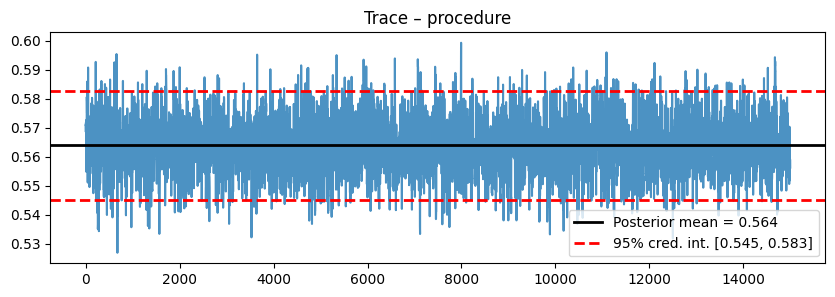

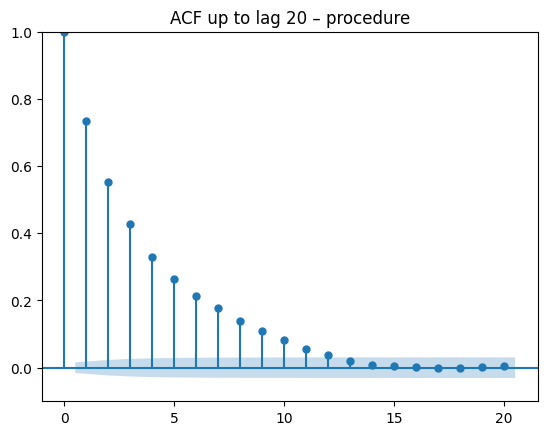

In [19]:
j_procedure = beta_names_poisson.index("procedure")
sample_procedure = samples_post_poisson[:, j_procedure]

mean_procedure = sample_procedure.mean()
ci_lower, ci_upper = np.percentile(sample_procedure, [2.5, 97.5])

plt.figure(figsize=(10, 3))
plt.plot(sample_procedure, alpha=0.8)

plt.axhline(mean_procedure, color="black", linewidth=2,
            label=f"Posterior mean = {mean_procedure:.3f}")
plt.axhline(ci_lower, color="red", linestyle="--", linewidth=2,
            label=f"95% cred. int. [{ci_lower:.3f}, {ci_upper:.3f}]")
plt.axhline(ci_upper, color="red", linestyle="--", linewidth=2)

plt.title("Trace – procedure")
plt.legend()
plt.show()

sm.graphics.tsa.plot_acf(sample_procedure, lags=20)
plt.title("ACF up to lag 20 – procedure")
plt.ylim(-0.1, 1)
plt.show()

In [20]:
out_rounded_poisson = out_rounded_poisson.sort_values("abs_z", ascending=False) 
report_poisson = (
    out_rounded_poisson[['CI 2.5%', 'FisherScoring_scratch','CI 97.5%']]
    .merge(
        summary_poisson[["2.5% cred. i.", "Post mean", "97.5% cred. i.", "Acceptance rate"]],
        left_index=True,
        right_index=True
    )
)
report_poisson

,CI 2.5%,FisherScoring_scratch,CI 97.5%,2.5% cred. i.,Post mean,97.5% cred. i.,Acceptance rate
intercept,1.8119,1.8310,1.8501,1.811931,1.830970,1.849869,0.444067
procedure,0.5457,0.5643,0.5829,0.545013,0.563923,0.582585,0.434867
type,0.0779,0.0943,0.1108,0.077133,0.094312,0.110706,0.435467
gender,-0.0654,-0.0489,-0.0325,-0.065391,-0.048812,-0.032401,0.440067
age,0.0267,0.0432,0.0597,0.026619,0.043434,0.060064,0.455600
died,-0.0571,-0.0412,-0.0254,-0.057751,-0.041606,-0.026074,0.425667
